
Load and explore the data





In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load
df = pd.read_csv('creditcard.csv')

print("Shape:", df.shape)
df.head()

Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Check for missing values:

In [7]:
print("Missing values:", df.isnull().sum().sum())

Missing values: 0


Class distribution:

In [34]:
class_counts = df['Class'].value_counts()
print(class_counts)
print(f"Fraud percentage: {class_counts[1]/len(df)*100:.4f}%")

Class
0    284315
1       492
Name: count, dtype: int64
Fraud percentage: 0.1727%


Statistical summary of Amount and Time:

In [8]:
df[['Amount', 'Time']].describe()

,Amount,Time
count,284807.000000,284807.000000
mean,88.349619,94813.859575
std,250.120109,47488.145955
min,0.000000,0.000000
25%,5.600000,54201.500000
50%,22.000000,84692.000000
75%,77.165000,139320.500000
max,25691.160000,172792.000000


Statistical summary of Amount and Time:

In [9]:
df[['Amount', 'Time']].describe()

,Amount,Time
count,284807.000000,284807.000000
mean,88.349619,94813.859575
std,250.120109,47488.145955
min,0.000000,0.000000
25%,5.600000,54201.500000
50%,22.000000,84692.000000
75%,77.165000,139320.500000
max,25691.160000,172792.000000


Histogram of Amount for normal vs fraud

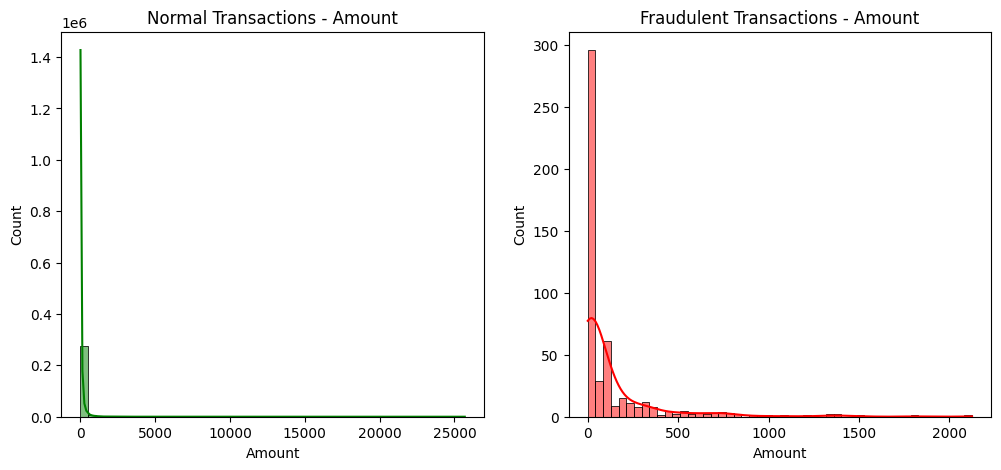

In [10]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df[df['Class']==0]['Amount'], bins=50, color='green', label='Normal', kde=True)
plt.title('Normal Transactions - Amount')
plt.subplot(1,2,2)
sns.histplot(df[df['Class']==1]['Amount'], bins=50, color='red', label='Fraud', kde=True)
plt.title('Fraudulent Transactions - Amount')
plt.show()

Boxplot (log scale because of wide range)

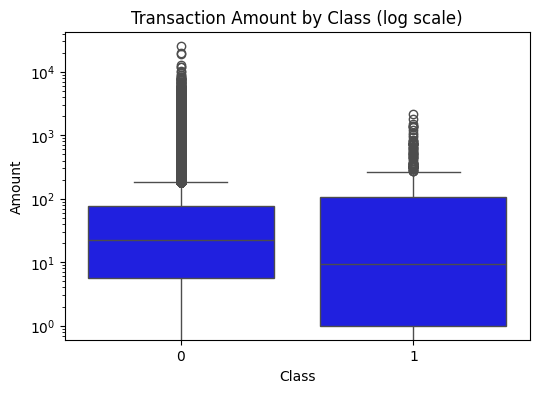

In [11]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Class', y='Amount', color='blue', data=df)
plt.yscale('log')
plt.title('Transaction Amount by Class (log scale)')
plt.show()

Transaction Time distribution

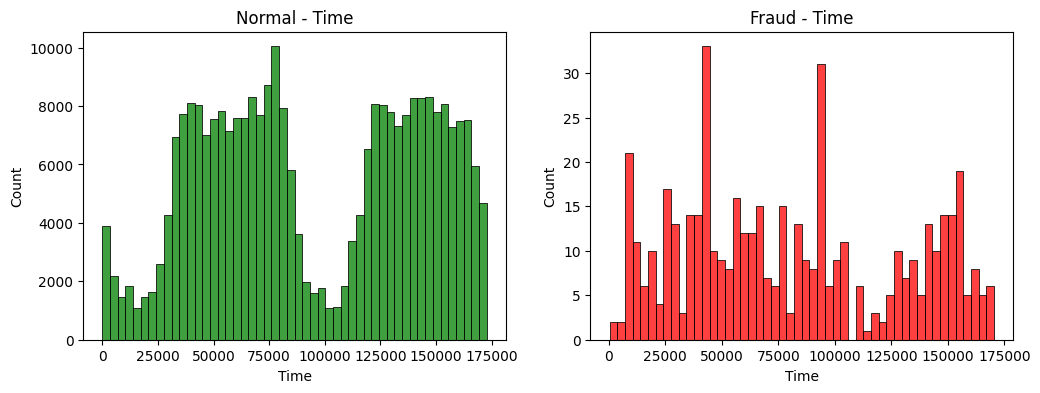

In [17]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.histplot(df[df['Class']==0]['Time'], bins=50, color='green')
plt.title('Normal - Time')
plt.subplot(1,2,2)
sns.histplot(df[df['Class']==1]['Time'], bins=50, color='red')
plt.title('Fraud - Time')
plt.show()

Amount

In [19]:


mean_amount = df['Amount'].mean()
std_amount = df['Amount'].std()
threshold = 3

df['amount_anomaly'] = (np.abs(df['Amount'] - mean_amount) > threshold * std_amount).astype(int)

print(f"Total anomalies flagged: {df['amount_anomaly'].sum()}")

Total anomalies flagged: 4076


Build confusion matrix values

In [20]:
tp = ((df['amount_anomaly'] == 1) & (df['Class'] == 1)).sum()
fp = ((df['amount_anomaly'] == 1) & (df['Class'] == 0)).sum()
tn = ((df['amount_anomaly'] == 0) & (df['Class'] == 0)).sum()
fn = ((df['amount_anomaly'] == 0) & (df['Class'] == 1)).sum()

print(f"TP: {tp}, FP: {fp}, TN: {tn}, FN: {fn}")

TP: 11, FP: 4065, TN: 280250, FN: 481


Calculate metrics

In [21]:
accuracy = (tp + tn) / len(df)
precision = tp / (tp + fp) if (tp+fp) > 0 else 0
recall = tp / (tp + fn) if (tp+fn) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision+recall) > 0 else 0

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 score:  {f1:.4f}")

Accuracy:  0.9840
Precision: 0.0027
Recall:    0.0224
F1 score:  0.0048


Show confusion matrix nicely

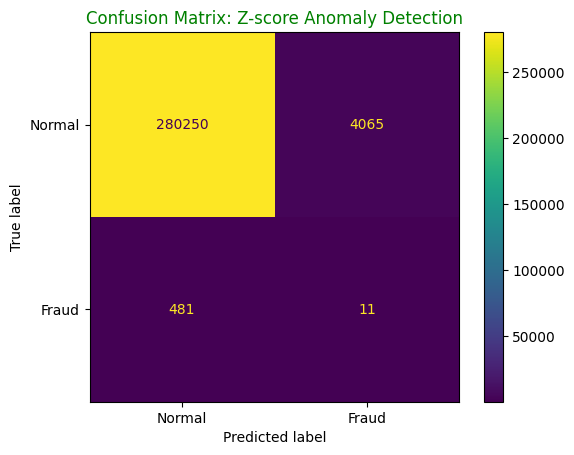

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(df['Class'], df['amount_anomaly'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Fraud'])
disp.plot()
plt.title('Confusion Matrix: Z-score Anomaly Detection', color='green')
plt.show()

flagging the top 1% of amounts:

In [33]:
percentile_99 = df['Amount'].quantile(0.99)
df['amount_anomaly_perc'] = (df['Amount'] > percentile_99).astype(int)

tp2 = ((df['amount_anomaly_perc'] == 1) & (df['Class'] == 1)).sum()
fn2 = ((df['amount_anomaly_perc'] == 0) & (df['Class'] == 1)).sum()
recall2 = tp2 / (tp2 + fn2)
print(f"Recall with top 1% rule: {recall2:.4f}")

Recall with top 1% rule: 0.0183


Build confusion matrix values